# Heisenberg Chain Benchmark

This notebook exercises the non-molecule expert-mode API with a four-site open XXZ Heisenberg chain:

`H = J sum_i (X_i X_{i+1} + Y_i Y_{i+1} + Delta Z_i Z_{i+1})`

It sweeps the anisotropy `Delta` and compares exact diagonalization, VQE, VarQITE, and QPE. The benchmark is meant to complement the chemistry notebooks with a compact correlated-spin model.

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pennylane as qml
from IPython.display import display

from qite import run_qite
from qpe import run_qpe
from vqe import run_vqe

N_QUBITS = 4
J = 1.0
DELTA_GRID = [0.0, 0.5, 1.0, 1.5, 2.0]
REFERENCE_STATE = [1, 0, 1, 0]

# VQE parameters
VQE_STEPS = 75

# QITE parameters
QITE_STEPS = 60
QITE_DTAU = 0.05
QITE_REG = 1e-4

# QPE parameters
QPE_ANCILLAS = 5
QPE_TIME = 1.0
QPE_TROTTER_STEPS = 2

# Ansatz parameters
ANSATZ_NAME = "auto"
ANSATZ_KWARGS = {"layers": 4}


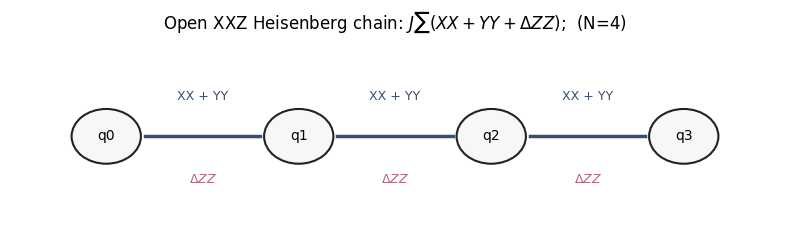

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.4))

site_x = np.arange(N_QUBITS, dtype=float)
for wire, x in enumerate(site_x):
    ax.add_patch(plt.Circle((x, 0), 0.18, facecolor="#f7f7f7", edgecolor="#222222", linewidth=1.5))
    ax.text(x, 0.0, f"q{wire}", ha="center", va="center", fontsize=10)

for wire in range(N_QUBITS - 1):
    ax.plot([wire + 0.2, wire + 0.8], [0, 0], color="#355070", linewidth=2.5)
    ax.text(wire + 0.5, 0.22, "XX + YY", ha="center", va="bottom", fontsize=9, color="#355070")
    ax.text(wire + 0.5, -0.24, r"$\Delta ZZ$", ha="center", va="top", fontsize=9, color="#b56576")

ax.set_title(rf"Open XXZ Heisenberg chain: $J\sum (XX + YY + \Delta ZZ)$;  (N={N_QUBITS})")
ax.set_xlim(-0.5, N_QUBITS - 0.5)
ax.set_ylim(-0.55, 0.65)
ax.axis("off")
fig.tight_layout()
plt.show()

In [ ]:
def xxz_heisenberg_hamiltonian(num_qubits: int, *, j: float, delta: float) -> qml.Hamiltonian:
    coeffs = []
    ops = []
    for wire in range(num_qubits - 1):
        coeffs.extend([float(j), float(j), float(j) * float(delta)])
        ops.extend(
            [
                qml.PauliX(wire) @ qml.PauliX(wire + 1),
                qml.PauliY(wire) @ qml.PauliY(wire + 1),
                qml.PauliZ(wire) @ qml.PauliZ(wire + 1),
            ]
        )
    return qml.Hamiltonian(coeffs, ops)


def exact_lowest_energies(hamiltonian: qml.Hamiltonian, num_qubits: int, *, k: int = 2) -> np.ndarray:
    matrix = qml.matrix(hamiltonian, wire_order=list(range(num_qubits)))
    eigs = np.linalg.eigvalsh(np.asarray(matrix, dtype=complex))
    return np.sort(np.real(eigs))[:k]


In [ ]:
rows = []

for delta in DELTA_GRID:
    H = xxz_heisenberg_hamiltonian(N_QUBITS, j=J, delta=delta)
    exact_eigs = exact_lowest_energies(H, N_QUBITS, k=2)
    exact = float(exact_eigs[0])
    gap = float(exact_eigs[1] - exact_eigs[0])

    vqe_res = run_vqe(
        molecule=f"XXZ_N{N_QUBITS}_Delta{delta:g}",
        hamiltonian=H,
        num_qubits=N_QUBITS,
        reference_state=REFERENCE_STATE,
        ansatz_name=ANSATZ_NAME,
        ansatz_kwargs=ANSATZ_KWARGS,
        optimizer_name="Adam",
        steps=VQE_STEPS,
        plot=False,
        force=False,
    )

    qite_res = run_qite(
        molecule=f"XXZ_N{N_QUBITS}_Delta{delta:g}",
        hamiltonian=H,
        num_qubits=N_QUBITS,
        reference_state=REFERENCE_STATE,
        ansatz_name=ANSATZ_NAME,
        ansatz_kwargs=ANSATZ_KWARGS,
        steps=QITE_STEPS,
        dtau=QITE_DTAU,
        reg=QITE_REG,
        plot=False,
        show=False,
        force=False,
    )

    qpe_res = run_qpe(
        molecule=f"XXZ_N{N_QUBITS}_Delta{delta:g}",
        hamiltonian=H,
        hf_state=np.array(REFERENCE_STATE, dtype=int),
        system_qubits=N_QUBITS,
        n_ancilla=QPE_ANCILLAS,
        t=QPE_TIME,
        trotter_steps=QPE_TROTTER_STEPS,
        shots=None,
        plot=False,
        force=False,
    )

    rows.append(
        {
            "delta": float(delta),
            "exact_ground_energy": exact,
            "exact_gap": gap,
            "vqe_energy": float(vqe_res["energy"]),
            "qite_energy": float(qite_res["energy"]),
            "qpe_energy": float(qpe_res["energy"]),
            "vqe_abs_error": abs(float(vqe_res["energy"]) - exact),
            "qite_abs_error": abs(float(qite_res["energy"]) - exact),
            "qpe_abs_error": abs(float(qpe_res["energy"]) - exact),
            "qpe_best_bitstring": qpe_res["best_bitstring"],
            "qpe_best_probability": float(qpe_res["probs"][qpe_res["best_bitstring"]]),
            "vqe_runtime_s": float(vqe_res.get("compute_runtime_s", np.nan)),
            "qite_runtime_s": float(qite_res.get("compute_runtime_s", np.nan)),
            "qpe_runtime_s": float(qpe_res.get("compute_runtime_s", np.nan)),
        }
    )

summary_df = pd.DataFrame(rows)
display(summary_df.round(8))


In [ ]:
method_series = {
    "exact": {"energy": "exact_ground_energy", "color": "#222222"},
    "VQE": {"energy": "vqe_energy", "error": "vqe_abs_error", "color": "#355070"},
    "VarQITE": {"energy": "qite_energy", "error": "qite_abs_error", "color": "#b56576"},
    "QPE dominant phase": {"energy": "qpe_energy", "error": "qpe_abs_error", "color": "#6d597a"},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

handles = []
for label, spec in method_series.items():
    (line,) = axes[0].plot(
        summary_df["delta"],
        summary_df[spec["energy"]],
        marker="o",
        color=spec["color"],
        label=label,
    )
    handles.append(line)
axes[0].set_title("Energy vs XXZ anisotropy")
axes[0].set_xlabel("Delta")
axes[0].set_ylabel("energy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(summary_df["delta"], summary_df["exact_gap"], marker="o", color="#2a9d8f")
axes[1].set_title("Exact first excitation gap")
axes[1].set_xlabel("Delta")
axes[1].set_ylabel("gap")
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"Open XXZ Heisenberg chain benchmark (N={N_QUBITS}, J={J})", y=0.99)
fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 0.92))
fig.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.8))

handles = []
for label, spec in method_series.items():
    if "error" not in spec:
        continue
    (line,) = ax.semilogy(
        summary_df["delta"],
        summary_df[spec["error"]],
        marker="o",
        color=spec["color"],
        label=label,
    )
    handles.append(line)
ax.set_title("Absolute error to exact ground")
ax.set_xlabel("Delta")
ax.set_ylabel("absolute error")
ax.grid(True, alpha=0.3)
fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 0.98))
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


## Notes

- The Neel reference state is a physically useful starting point for the antiferromagnetic chain, but it is not generally an exact eigenstate.
- The exact gap is included because small gaps make variational convergence and QPE phase selection harder.
- This is a compact four-site benchmark; use it to validate expert-mode behavior before increasing chain length or ansatz depth.
- XXZ uses `ANSATZ_NAME = "auto"`; the selector should resolve this Hamiltonian to `XXZ-HVA`, with excitation-preserving exchange rotations plus ZZ phases on even and odd bonds. The selected ansatz is reported in the run result.
- The low-depth XXZ ansatz is still a variational approximation; increase `ANSATZ_KWARGS["layers"]`, seeds, or optimizer budget before treating isotropic Heisenberg points as converged physics.
